In [47]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [49]:
def f(x):
    return 3*x**2 - 4*x + 5

In [50]:
f(3.0)

20.0

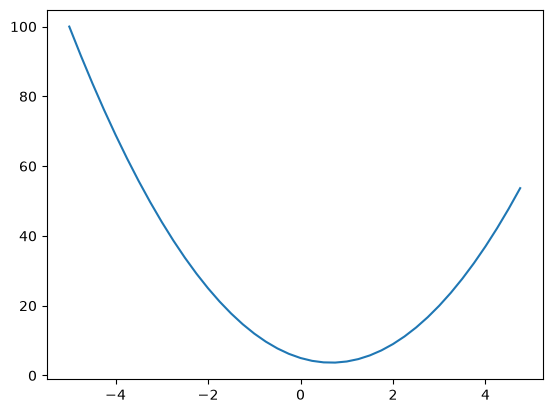

In [51]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)

In [52]:
h=0.0000001
x=2/3
(f(x + h) - f(x)) / h


2.9753977059954195e-07

In [53]:
a=2
b=-3
c=10

d=a*b+c
print(d)

4


In [54]:
h=0.00001
a=2
b=-3
c=10

d1=a*b+c
c+=h
d2=a*b+c
print((d2-d1)/h)


0.9999999999621422


In [55]:
# brew install graphviz
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
import os
os.environ["PATH"] = r"C:\Program Files\Graphviz\bin" + os.pathsep + os.environ.get("PATH", "")
from graphviz import Digraph

In [57]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [113]:
class Value:
    def __init__(self,data, _children=(), op='', label=''):
        self.data=data
        self.grad=0.0

        self._prev=set(_children)
        self._op=op
        self.label=label
        self._backward=lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, _children=(self, other), op='+', label=f'({self.label}+{other.label})')

        def backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, _children=(self, other), op='*', label=f'({self.label}*{other.label})')

        def backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self + (-other)

    def __pow__(self, exponent):
        out = Value(self.data ** exponent, _children=(self,), op=f'**{exponent}')

        def backward():
            self.grad += exponent * self.data ** (exponent - 1) * out.grad
        out._backward = backward
        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, _children=(self,), op='ReLU', label=f'ReLU({self.label})')
        def backward():
            self.grad += (self.data > 0) * out.grad
        out._backward = backward
        return out

    def tanh(self):
        t = (math.exp(2*self.data) - 1) / (math.exp(2*self.data) + 1)
        out = Value(t, _children=(self,), op='tanh', label=f'tanh({self.label})')
        def backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = backward
        return out

    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [59]:
x1=Value(2.0, label='x1')
x2=Value(-3.0, label='x2')
w1=Value(2.0, label='w1')
w2=Value(1.0, label='w2')
b=Value(5.0, label='b')

x1w1 = x1*w1
x2w2 = x2*w2
x1w1x2w2 = x1w1 + x2w2
n = x1w1x2w2 + b
n.label = 'n'
o=n.relu()

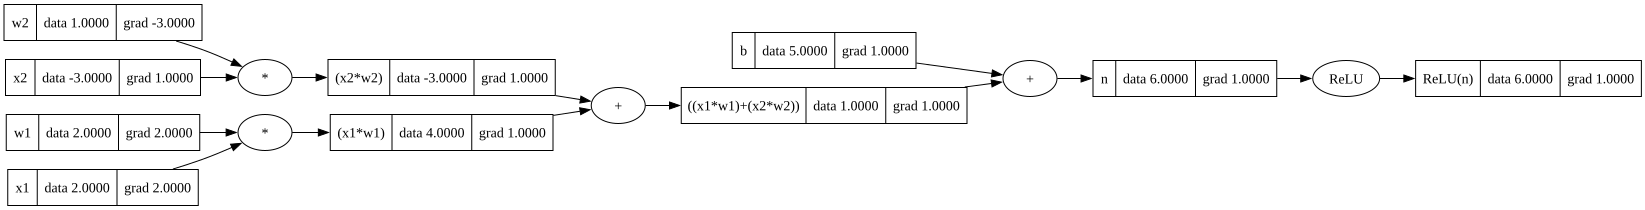

In [67]:
draw_dot(o, format='svg', rankdir='LR')

In [61]:
# h=0.0001
# b+=h
# o2=x1*w1 + x2*w2 + b

In [62]:
# (o2.data - o.data) / h

In [63]:
# o.grad = 1.0
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()

In [64]:
o.backward()

In [65]:
import torch
import random

In [188]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

x=[2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)


[Value(data=-0.9175206477338103)]

In [189]:
xs=[[2.0, 3.0, -1.0], [-1.0, -2.0, 3.0], [3.0, 1.0, 2.0], [1.0, 2.0, 3.0]]
y = [1.0,-1.0,-1.0,1.0]
y_pred=[n(x) for x in xs]
y_pred

[[Value(data=-0.9175206477338103)],
 [Value(data=-0.28327503472780075)],
 [Value(data=-0.9352340665627127)],
 [Value(data=-0.9414856016757439)]]

In [190]:
loss = sum(((yout[0] - ygt) ** 2 for yout, ygt in zip(y_pred, y)), Value(0))
loss

Value(data=7.964141077978155)

In [191]:
loss.backward()

In [178]:
# n.layers[0].neurons[0].w[0].grad

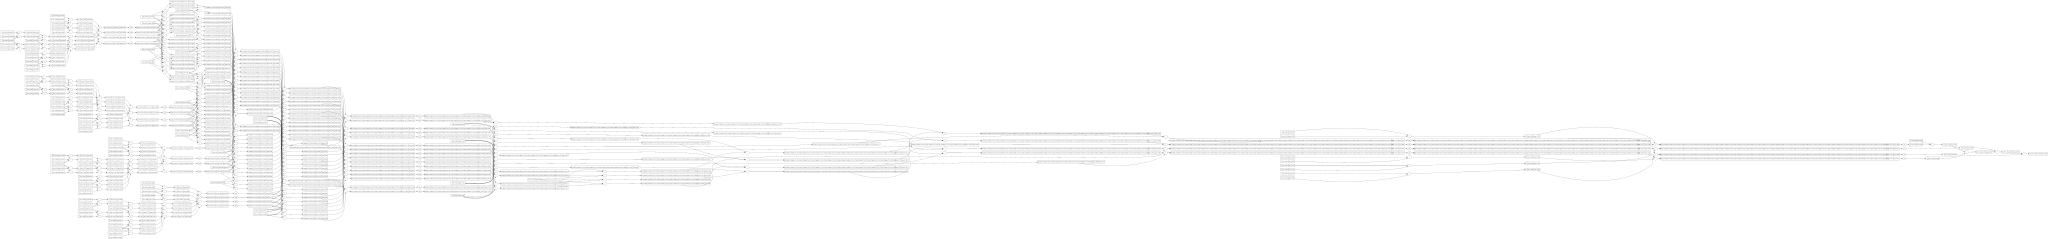

In [192]:
draw_dot(loss, format='svg', rankdir='LR')

In [195]:
for i in range(6000):
    y_pred=[n(x) for x in xs]
    loss = sum(((yout[0] - ygt) ** 2 for yout, ygt in zip(y_pred, y)), Value(0))

    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    
    for p in n.parameters():
        p.data += -0.3 * p.grad
    print(i, loss.data)

0 1.4744865777017501e-05
1 1.474215690096822e-05
2 1.4739449006517296e-05
3 1.4736742093134243e-05
4 1.4734036160290267e-05
5 1.4731331207456755e-05
6 1.4728627234105873e-05
7 1.4725924239707197e-05
8 1.472322222373381e-05
9 1.4720521185658361e-05
10 1.4717821124954941e-05
11 1.4715122041094767e-05
12 1.4712423933553481e-05
13 1.4709726801803e-05
14 1.470703064531986e-05
15 1.4704335463577812e-05
16 1.470164125605291e-05
17 1.4698948022218691e-05
18 1.4696255761553483e-05
19 1.4693564473532657e-05
20 1.4690874157633334e-05
21 1.4688184813331238e-05
22 1.4685496440105129e-05
23 1.4682809037431693e-05
24 1.4680122604790065e-05
25 1.4677437141658767e-05
26 1.4674752647516087e-05
27 1.467206912184221e-05
28 1.4669386564116337e-05
29 1.4666704973818257e-05
30 1.4664024350427796e-05
31 1.466134469342877e-05
32 1.4658666002298206e-05
33 1.4655988276520755e-05
34 1.4653311515576315e-05
35 1.4650635718948536e-05
36 1.4647960886118727e-05
37 1.464528701657085e-05
38 1.4642614109787484e-05
39 1.4

In [196]:
xs=[[2.0, 3.0, -1.0], [-1.0, -2.0, 3.0], [3.0, 1.0, 2.0], [1.0, 2.0, 3.0]]
y = [1.0,-1.0,-1.0,1.0]
y_pred=[n(x) for x in xs]
y_pred

[[Value(data=0.9987725392776022)],
 [Value(data=-0.9983902711509437)],
 [Value(data=-0.9990468750893362)],
 [Value(data=0.9985964893955126)]]